In [1]:
from aperture_sum import ap_sum

import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.colors as colors
import numpy as np
from photutils.aperture import CircularAperture

from astropy.visualization import ImageNormalize, ManualInterval
from matplotlib import pyplot as plt

from datetime import datetime
from matplotlib.colors import LogNorm

import matplotlib.dates as md

In [2]:
#since file size is too big to put on github, navigate to wherever MAST_CMD they are saved on your machine

In [3]:
cd /Users/ibehbehani/

/Users/ibehbehani


In [4]:
from astropy.io import fits

In [5]:
fits_475 = fits.open('MAST_CMD/J6LL01010_475/j6ll01010_drz.fits')
fits_550 = fits.open('MAST_CMD/J6LL01YGQ_555/j6ll01ygq_drz.fits')

In [6]:
exp_475 = fits_475[0].header['EXPTIME']
exp_550 = fits_550[0].header['EXPTIME']

In [7]:
coords_475 = (1636, 2386)
coords_550 = (1625, 2365)

In [8]:
from photutils.aperture import aperture_photometry, ApertureStats
from photutils.aperture import CircularAperture

In [9]:
def ap_phot(data,coords,r):
    aperture = CircularAperture(coords, r=r)
    phot_table = aperture_photometry(data, aperture)
    phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
    print(phot_table)
    # allow for error calculations in aperture
    apstats = ApertureStats(data, aperture)

    return phot_table['aperture_sum'][0]

In [10]:
sum_475 = ap_phot(fits_475[1].data,coords_475,r=3)

 id x_center y_center aperture_sum
--- -------- -------- ------------
  1   1636.0   2386.0    108.64009


In [11]:
sum_550 = ap_phot(fits_550[1].data,coords_550,r=3)

 id x_center y_center aperture_sum
--- -------- -------- ------------
  1   1625.0   2365.0    112.48937


In [12]:
b_minus_v = -2.5 * np.log10(sum_475/sum_550)
print(b_minus_v)

0.03780345712332077


In [13]:
from acstools import acszpt


In [14]:
q = acszpt.Query(date='2002-07-07', detector='WFC', filt='F555W')
filter_zpt = q.fetch()

In [15]:
flux_inf = sum_550/0.74
# Now convert instrumental fluxes to physical fluxes and magnitudes.
# F_lambda is the flux density in units of erg/sec/cm^2/Angstrom.
F_lambda = flux_inf * filter_zpt['PHOTFLAM']
m_st = -2.5 * np.log10(flux_inf) + filter_zpt['STmag'][0].value
m_ab = -2.5 * np.log10(flux_inf) + filter_zpt['ABmag'][0].value
m_vega = -2.5 * np.log10(flux_inf) + filter_zpt['VEGAmag'][0].value

print()

# Assemble the values into an Astropy Table. Note that we could
# attach units to these columns, however advanced Astropy
# Tables use is outside the scope of this example.
print('Measured Flux', sum_550, '\nF_lambda', F_lambda,
                    '\nST Mag', m_st, '\nAB Mag', m_ab, '\nVega Mag', m_vega)


Measured Flux 112.48936938162402 
F_lambda [2.9475255e-17] erg / (Angstrom electron cm2) 
ST Mag 20.226300594032217 
AB Mag 20.272300594032217 
Vega Mag 20.28330059403222


In [16]:
b = 20.2
b = 2.5 * np.log10(sum_550)

print(b)

5.127778705295222


In [17]:
M_b = 20.2 - 5*np.log10(4450) +5
M_b

np.float64(6.958199945095341)

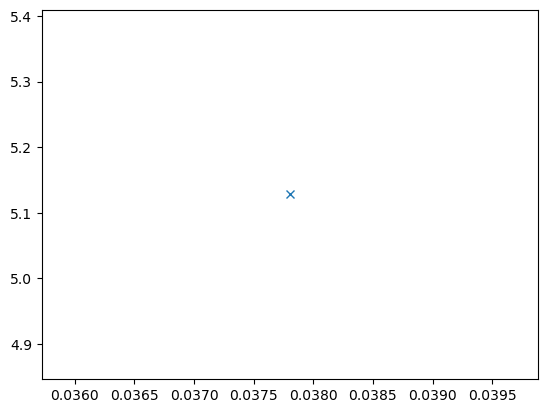

In [18]:
plt.plot(b_minus_v,b,'x')
